In [1]:
import lseg.data as ld
from lseg.data.discovery import Screener
from datetime import date, timedelta
import plotly.express as px

ld.open_session()

miner = Screener('U(IN(Equity(active,public,primary))/*UNV:Public*/), IN(TR.TRBCActivityCode,"5120106011"), IN(TR.GICSSubIndustryCode,"15104030"), CURN=USD')

print(list(miner))

['AU.N', 'KORE.V', 'RSG.AX', 'LUG.TO', 'GGA.V', 'RIO.TO', 'AEM.TO', 'JAG.TO', 'ABX.TO', 'GPG.V', 'VGZ.A', 'ASIh.V', 'CMCL.A', 'TXG.TO', 'DPM.TO', 'GLB.V', 'ARIS.TO', 'LORD.V', 'ITH.TO', 'GGM.V', 'RUP.TO', 'LKAI.PK', 'DYG.V', 'SKP.V', 'BRAU.V', 'ATX.V', 'CCM.TO', 'CGD.V', 'WDO.TO', 'STLR.TO', 'CDE.N', 'GPLDQ.PK', 'CQR.V', 'SSRM.OQ', 'NEM.N', 'NMGh.V', 'CVB.V', 'NG.A', 'WRLG.V', 'GDX.V', 'ALK.AX', 'GA8.AX', 'BEAR.V', 'HRZ.AX', 'SVG.AX', 'K.TO', 'RRL.AX', 'LC.PS', 'RDS.V', 'RBX.V', 'RGLD.OQ', 'ELD.TO', 'TAM.AX', 'WPM.TO', 'RPX.V', 'RND.AX', 'THX.V', 'BSX.TO', 'KLDC.V', 'STRM.V', 'SAFh.V', 'TBR.AX', 'ROS.V', 'FVI.TO', 'MAS.CN', 'GG8.AX', 'MJS.V', 'HSTR.V', 'AS1.AX', 'PNR.AX', 'KCN.AX', 'AAU.AX', 'GRMC.PK', 'VAU.AX', 'THMG.PK', 'RNGJ.J', 'DRDJ.J', 'TRX.A', 'EDV.TO', 'GAU.TO', 'MAOMF.PK', 'AAR.AX', 'SBM.AX', 'JUBh.V', 'IMG.TO', 'UGD.V', '0621.HK', 'CTO.AX', 'AB.PS', 'MMY.V', 'SOI.V', 'SPA.V', 'SGRCF.PK', 'LIO.V', 'FML.AX', 'PAFR.L', 'CGNR.L', 'WINS.V', 'MEK.AX', 'RML.V', 'GETTh.V', 'BARU.V',

In [2]:
len(list(miner))

314

In [3]:
fundamentals = ld.get_data(
    universe = miner,
    fields = [
        "TR.Revenue",
        "TR.GrossProfit"
    ]
)
fundamentals

,Instrument,Revenue,Gross Profit
0,AU.N,9893000000,4874000000
1,KORE.V,<NA>,<NA>
2,RSG.AX,872200000,316300000
3,LUG.TO,1782940000,1226337000
4,GGA.V,20369000,1973000
...,...,...,...
309,PC2.AX,63940,<NA>
310,EMAS.JK,131960,-146000
311,SNM.AX,<NA>,<NA>
312,MBG.AX,<NA>,<NA>


In [4]:
df = fundamentals.dropna(subset=["Revenue", "Gross Profit"]).copy()

# Remove zero revenues (explorers)
df = df[df["Revenue"] > 0]

# Compute margin
df["GrossMarginPct"] = df["Gross Profit"] / df["Revenue"] * 100

# ---- REMOVE OUTLIERS ----

# 1. Revenue too large (likely not miners)
df = df[df["Revenue"] < 2e11]     # < 200 billion USD

# 2. Remove microscopic companies (not producers)
df = df[df["Revenue"] > 1e6]      # > 1 million USD revenue

# 3. Remove insane gross margin outliers
df = df[(df["GrossMarginPct"] > -100) & (df["GrossMarginPct"] < 100)]

# Optional: Remove negative margins if you want to focus on producers
# df = df[df["GrossMarginPct"] > 0]

df


,Instrument,Revenue,Gross Profit,GrossMarginPct
0,AU.N,9893000000,4874000000,49.267159
2,RSG.AX,872200000,316300000,36.264618
3,LUG.TO,1782940000,1226337000,68.781731
4,GGA.V,20369000,1973000,9.686288
6,AEM.TO,11907851000,8567167000,71.945534
...,...,...,...,...
291,001337.SZ,639833980,339400230,53.045046
298,PAMPALO.HE,45500000,26800000,58.901099
301,AAUC.TO,730382000,220234000,30.153262
302,UGLD.MM,75883000000,26247000000,34.588775


In [5]:
end = date.today().strftime("%Y-%m-%d")
start = (date.today() - timedelta(days=365)).strftime("%Y-%m-%d")

gold_history = ld.get_history(
    universe="XAUFIX=",
    fields=["TRDPRC_1"],
    interval="1D",
    start=start,
    end=end
)
gold_history

XAUFIX=,TRDPRC_1
Date,
2025-04-01,3133.7
2025-04-02,3119.75
2025-04-03,3118.1
2025-04-04,3054.5
2025-04-07,3014.75
...,...
2026-03-24,4413.55
2026-03-25,4564.55
2026-03-26,4456.45


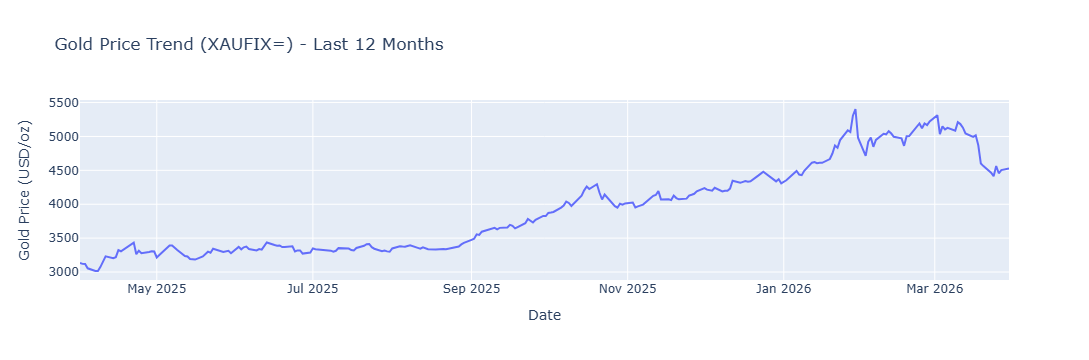

In [6]:
fig = px.line(
    gold_history,
    x=gold_history.index,
    y="TRDPRC_1",
    title="Gold Price Trend (XAUFIX=) - Last 12 Months",
    labels={"TRDPRC_1": "Gold Price (USD/oz)"}
)
fig.show()

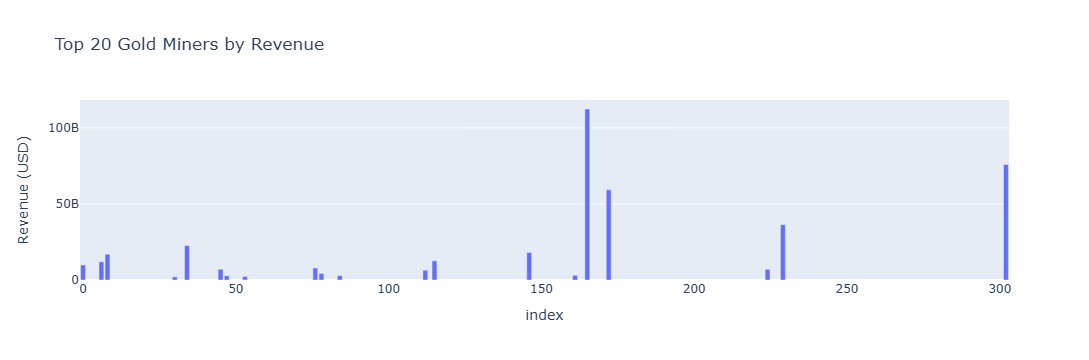

In [7]:
df_rev = df.sort_values("Revenue", ascending=False).head(20)

fig = px.bar(
    df_rev,
    x=df_rev.index,
    y="Revenue",
    title="Top 20 Gold Miners by Revenue",
    labels={"Revenue": "Revenue (USD)"}
)
fig.show()

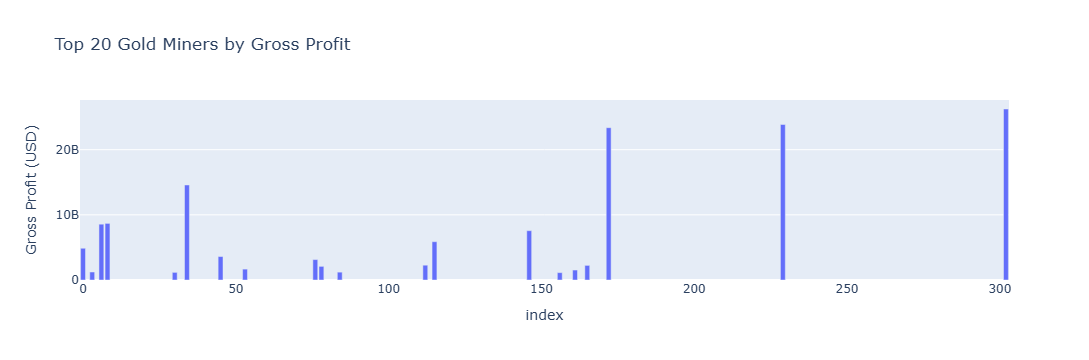

In [8]:
df_gp = df.sort_values("Gross Profit", ascending=False).head(20)

fig = px.bar(
    df_gp,
    x=df_gp.index,
    y="Gross Profit",
    title="Top 20 Gold Miners by Gross Profit",
    labels={"Gross Profit": "Gross Profit (USD)"}
)
fig.show()

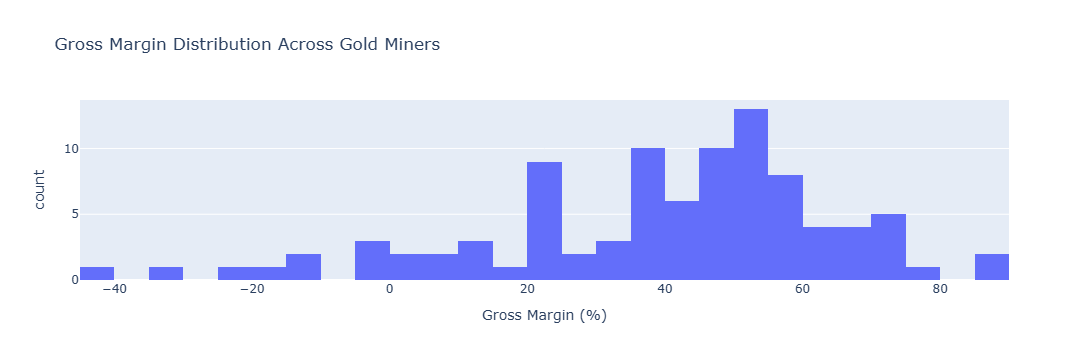

In [9]:
fig = px.histogram(
    df,
    x="GrossMarginPct",
    nbins=30,
    title="Gross Margin Distribution Across Gold Miners",
    labels={"GrossMarginPct": "Gross Margin (%)"}
)
fig.show()

In [10]:
df["BubbleSize"] = df["GrossMarginPct"].abs()

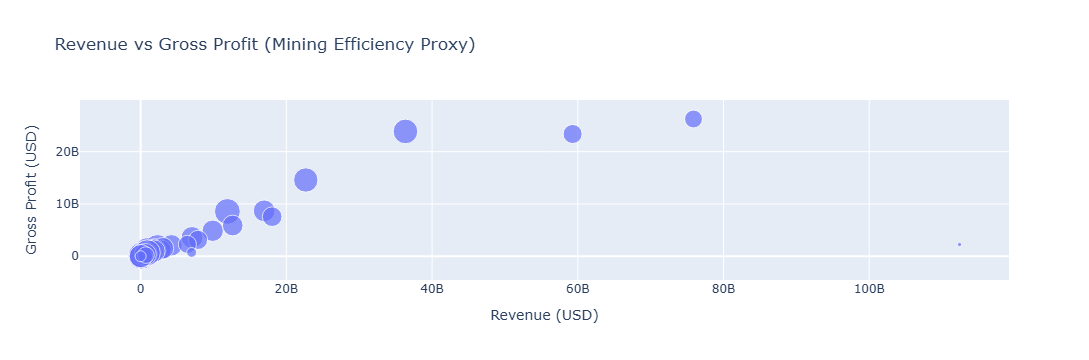

In [11]:
fig = px.scatter(
    df,
    x="Revenue",
    y="Gross Profit",
    size="BubbleSize",
    hover_name=df.index,
    title="Revenue vs Gross Profit (Mining Efficiency Proxy)",
    labels={
        "Revenue": "Revenue (USD)",
        "Gross Profit": "Gross Profit (USD)"
    }
)
fig.show()

In [12]:
dashboard = df[["Revenue", "Gross Profit", "GrossMarginPct"]]
dashboard.sort_values("GrossMarginPct", ascending=False).head(20)

,Revenue,Gross Profit,GrossMarginPct
50,1030471000,890940000,86.459493
49,222431000,190721000,85.743894
209,128374420,97924460,76.280352
192,595249000,438337000,73.639267
253,913939000,670658000,73.381046
119,38155000,27570000,72.257895
53,2314600000,1671648000,72.221896
6,11907851000,8567167000,71.945534
252,580665000,399958000,68.879302
3,1782940000,1226337000,68.781731


In [13]:
ld.close_session()